# Test file


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Loading Data for first car in KIT DATASET

In [2]:
Leon1_table = pd.read_csv("Leon1.csv")

In [3]:
Leon1_table.shape # checking the shape of table to confirm correct loading of data

(46349, 11)

## 2.Functions

In [4]:

    
def acceleration(speed_data, time_data):
   
    speed_data = pd.Series(speed_data)
    time_data = pd.Series(time_data)
    
   
    dv = speed_data.diff()          
    dt = time_data.diff() 
    
    
    a = dv / dt
    
    # Optional: remove invalid entries (first row will be NaN)
    a = a.fillna(0)
    
    return a

## 3.Basics graphs



#### Preprocessing time data(neccessary to extract time from dataset correctly)

In [5]:

Leon1_table['Time'] = pd.to_datetime(Leon1_table['Time'], format='%H:%M:%S.%f')


#print(Leon1_table['Time'].head())

Leon1_table['elapsed time'] = (Leon1_table['Time'] - Leon1_table['Time'].iloc[0]).dt.total_seconds()

#print(Leon1_table['elapsed time'].head(10))







### 3.1 speed Vs time




#### 3.1.1 Speed vs time in km/h

Text(0.5, 1.0, 'figure 1: speed v time km/h; first 60 seconds')

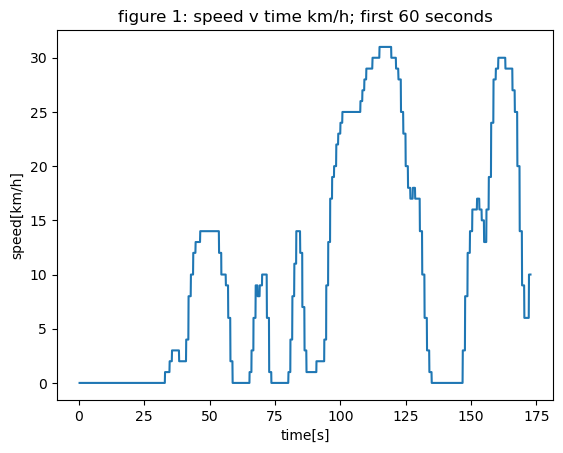

In [6]:
plt.plot(Leon1_table['elapsed time'].head(2000),Leon1_table['Vehicle Speed Sensor [km/h]'].head(2000) ) # PLOT FOR FIRST 700 DATA POINTS
plt.xlabel('time[s]')
plt.ylabel('speed[km/h]')
plt.title('figure 1: speed v time km/h; first 60 seconds')

#### 3.1.2 Speed v time in m/s

##### converting speed into m/s and adding a new column to the dataframe

In [7]:
Leon1_table['vehicle speed [m/s]'] = Leon1_table['Vehicle Speed Sensor [km/h]']*(5/18)   #CONVERTING SPEED TO M/S

#Leon1_table.columns = Leon1_table.columns.str.strip()



Text(0.5, 1.0, 'figure 2: speed v time m/s; first 60 seconds')

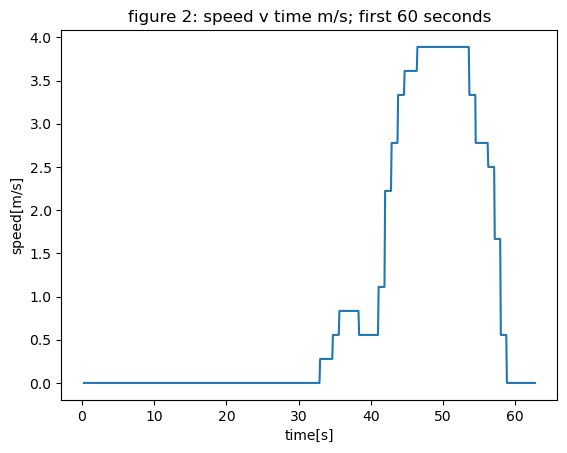

In [8]:
plt.plot(Leon1_table['elapsed time'].head(700),Leon1_table['vehicle speed [m/s]'].head(700) )
plt.xlabel('time[s]')
plt.ylabel('speed[m/s]')
plt.title('figure 2: speed v time m/s; first 60 seconds')

### 3.2 acceleration vs time

I have tested two ways to calculate acceleration:

first way is using the acceleration function I coded under "Functions" section above.
second way using numpys "np.gradient"

second way makes graph more smooth/ less pointy so this way is better.

#### 3.2.1  using custom acceleration function

In [9]:
Leon1_table['acceleration custom [m/s^2]'] = acceleration(Leon1_table['vehicle speed [m/s]'],Leon1_table['elapsed time']) #using acceleration function

Text(0.5, 1.0, 'figure 3: acceleration vs time using custom function for entire dataset')

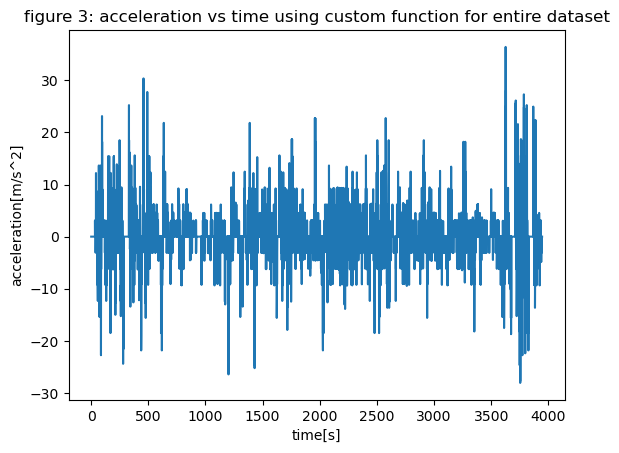

In [10]:
plt.plot(Leon1_table['elapsed time'],Leon1_table['acceleration custom [m/s^2]'])
plt.xlabel('time[s]')
plt.ylabel('acceleration[m/s^2]')
plt.title('figure 3: acceleration vs time using custom function for entire dataset')

##### section of above graph for visualisation purposes

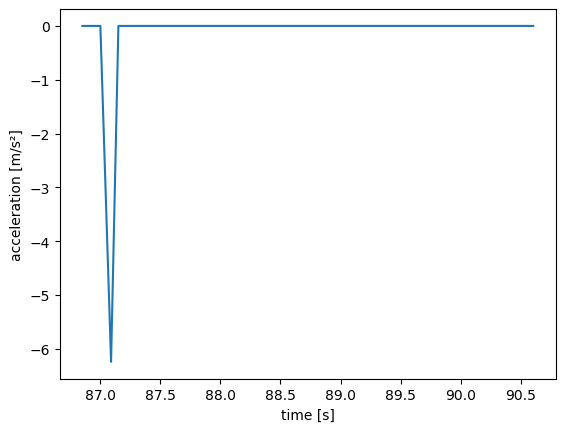

In [11]:
plt.plot(
    Leon1_table['elapsed time'].iloc[1000:1050],
    Leon1_table['acceleration custom [m/s^2]'].iloc[1000:1050]
)
plt.xlabel('time [s]')
plt.ylabel('acceleration [m/s²]')
plt.show()

#### 3.2.2 using np.gradient method for acceleration

In [12]:
a = np.gradient(Leon1_table['vehicle speed [m/s]'], Leon1_table['elapsed time'])

Leon1_table['acceleration np [m/s^2]'] = a



Text(0.5, 1.0, 'figure 4: acceleration vs time using np.gradient function; for entire dataset')

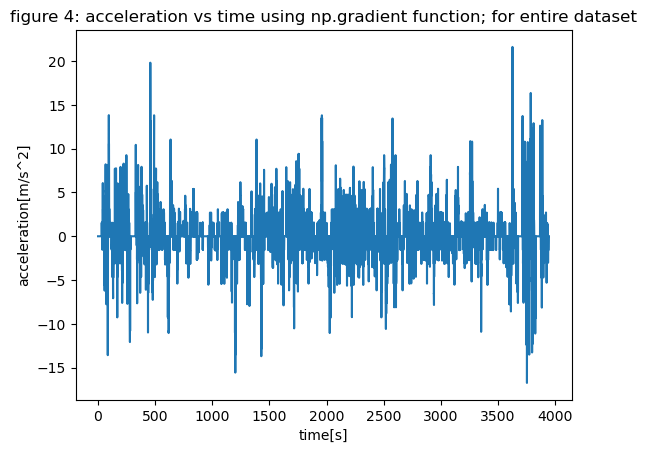

In [13]:
plt.plot(Leon1_table['elapsed time'],Leon1_table['acceleration np [m/s^2]'])
plt.xlabel('time[s]')
plt.ylabel('acceleration[m/s^2]')
plt.title('figure 4: acceleration vs time using np.gradient function; for entire dataset')


#### 3.2.3 plots comparing custom acceleration vs np acceleration

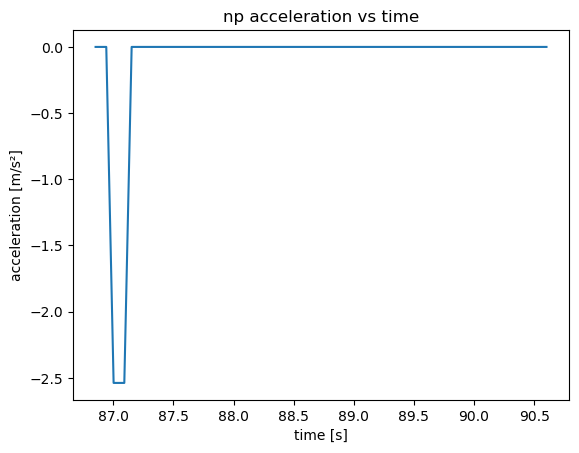

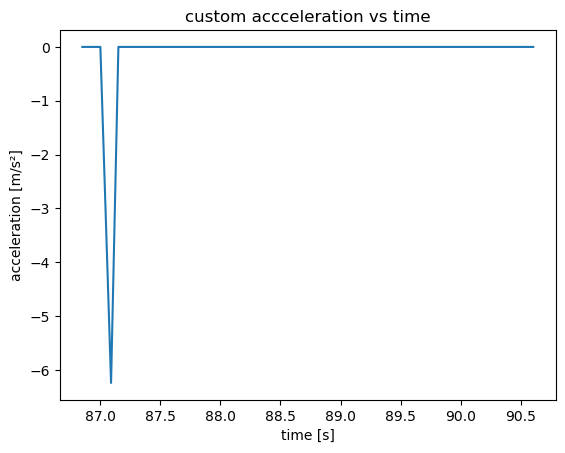

In [14]:
plt.plot(
    Leon1_table['elapsed time'].iloc[1000:1050],
    Leon1_table['acceleration np [m/s^2]'].iloc[1000:1050]
)
plt.xlabel('time [s]')
plt.ylabel('acceleration [m/s²]')
plt.title("np acceleration vs time")
plt.show()

##-------------------------------------------------------------------------------------------##

plt.plot(
    Leon1_table['elapsed time'].iloc[1000:1050],
    Leon1_table['acceleration custom [m/s^2]'].iloc[1000:1050]
)
plt.xlabel('time [s]')
plt.ylabel('acceleration [m/s²]')
plt.title("custom accceleration vs time")
plt.show()

Conclusion As we can see plot 1 looks smoother so we should probably stick with that method from now on

#### 3.2.4 np acceleration vs time for section of data (From data point 1000 to data point 2000)

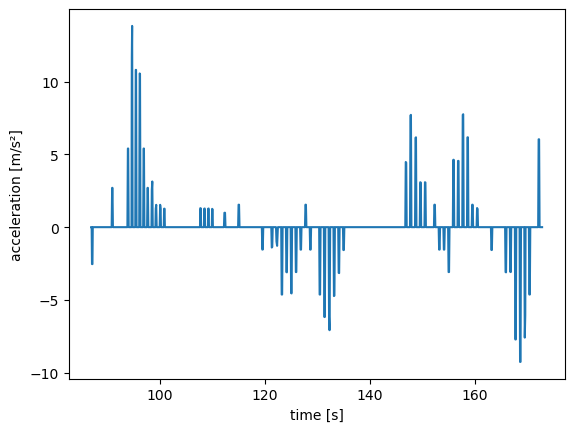

In [15]:
plt.plot(
    Leon1_table['elapsed time'].iloc[1000:2000],
    Leon1_table['acceleration np [m/s^2]'].iloc[1000:2000]
)
plt.xlabel('time [s]')
plt.ylabel('acceleration [m/s²]')
plt.show()

### 3.3 gear estimation plot

Text(0.5, 1.0, 'figure 5: speed(km/h) vs engine rpm; for gear finding')

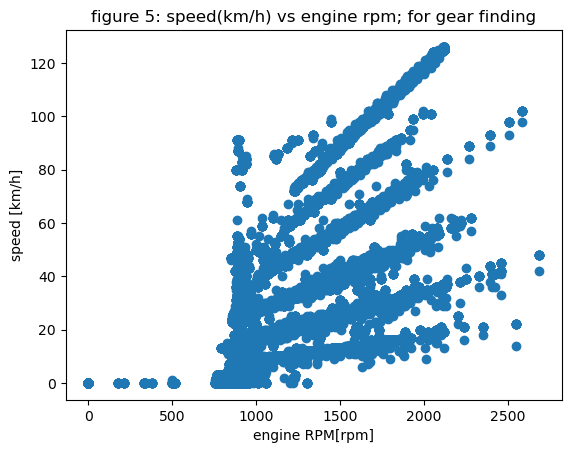

In [16]:
plt.plot(Leon1_table['Engine RPM [RPM]'],Leon1_table['Vehicle Speed Sensor [km/h]'],'o')
plt.xlabel('engine RPM[rpm]')
plt.ylabel('speed [km/h]')
plt.title('figure 5: speed(km/h) vs engine rpm; for gear finding')


# potential next steps:

1. clean data to remove outliers as seen in figure 5
2. plot gear position vs time(refer to figure 9 in "Modeling Vehicle Fuel Consumption Using a Low-Cost OBD-II Interface" document)(daniel)
3. plot braking vs time. (simply looking at when car breaks vs time).
4. start thinking about how to translate OBDII data to equation(1) in "A simulation model of the real-world fuel and energy consumption of light-duty vehicles" paper

## 4 Forces

the following calculates the longitudinal vehicle dynamics. It derives the dynamics using the force equation:

ftr = ffr + faero+ Fslope + fin.

this equation is widely used in automative engineering(insert source). I will derive each of the consitituent forces that make up this equation using partly OBDII data, some "standard" parameters(eg p) and some parameters that are vehicle specific(eg A=frontal Area).

### 4.1 Aerodynamic drag

this is calculated using the standard fluid drag equation: 0.5*p*c_d*A*v^2

p refers to air density which varies depending on height from sea level(there might be a way to find this or estimate this from OBDII data. for now let p= 1.17 kg/m^3
Cd refers to drag coefficient(again varies depending on vehicle shape). assume vheicle is a normal car for now let's assume Cd = 0.3
A again refering to frontal area, let it = 2.2 m^2( we can let the user input this.)


In [17]:
p = 1.17
Cd = 0.3
A= 2.2


Leon1_table['Faero [N]'] = 0.5*p*Cd*A* (Leon1_table['vehicle speed [m/s]'])**2


### 4.2 rolling resistance

Calculating using equation mu*Mveh*g*cos(theta)

where mu = rolling resistance coefficient. Mveh = vehicle mass. g = gravity acceleration. phi = slope angle. Let's assume  = 0 ie assume flat ground.

In [18]:
mu = 0.012
g = 9.81
m_vehicle = 1300
phi = 0
Leon1_table['Froll [N]'] = mu * m_vehicle * g * np.cos(phi)

### 4.3 grade 

road incline/slope. slope component of gravity


In [19]:
Leon1_table['Fslope [N]'] = m_vehicle * g * np.sin(phi)

### 4.4 Finertia

Force needed to accelerate the vehicle's mass in the direction of motion.

In [20]:
Leon1_table['Finertia [N]'] = m_vehicle * Leon1_table['acceleration np [m/s^2]']

### 4.5 Traction force

It is the force delivered by the tyres to the road to make the car move. corresponeds to engine torque

In [21]:
Leon1_table['Ftraction [N]'] = (
    Leon1_table['Faero [N]'] +
    Leon1_table['Froll [N]'] +
    Leon1_table['Fslope [N]'] +
    Leon1_table['Finertia [N]']
)

potential next action: find Ftraction in an alternative way. thereby being able to find acceleration and see how accurate our physics model is. Find a way to improve accuracy perhaps using ML methods.

In [22]:
# trying to find traction force using torque in order to reverse engineer 
#car acceleration

r_tyre = 0.318 # like this for now. usually a function of time but this will additional complexity so online static estimate for now.(search effective radius).

Leon1_table['Wheel torque [N*m]'] = r_tyre*(Leon1_table['Ftraction [N]'])

Leon1_table['Wheel Power [W]'] = (Leon1_table['vehicle speed [m/s]'])*(Leon1_table['Ftraction [N]'])


## Energies

In [23]:
N = min(2000, len(Leon1_table))
Leon_sub = Leon1_table.iloc[:N].copy()

# 2) Ensure elapsed time is float and has no NaN
Leon_sub['elapsed time'] = Leon_sub['elapsed time'].astype(float)
Leon_sub['elapsed time'] = Leon_sub['elapsed time'].fillna(method='ffill').fillna(0.0)

t = Leon_sub['elapsed time']

In [24]:
v = Leon_sub['vehicle speed [m/s]'].astype(float).fillna(0.0)

Leon_sub['Faero [N]']    = Leon_sub['Faero [N]'].astype(float).fillna(0.0)
Leon_sub['Froll [N]']    = Leon_sub['Froll [N]'].astype(float).fillna(0.0)
Leon_sub['Finertia [N]'] = Leon_sub['Finertia [N]'].astype(float).fillna(0.0)

# Power components
Leon_sub['P_aero [W]']    = Leon_sub['Faero [N]']    * v
Leon_sub['P_roll [W]']    = Leon_sub['Froll [N]']    * v
Leon_sub['P_inertia [W]'] = Leon_sub['Finertia [N]'] * v


Leon_sub['Wheel Power [W]'] = Leon_sub['Wheel Power [W]'].astype(float).fillna(0.0)
Leon_sub['P_total_wheel [W]'] = Leon_sub['Wheel Power [W]']

# Split into drive / brake and make sure no NaNs
Leon_sub['P_drive [W]'] = np.clip(Leon_sub['P_total_wheel [W]'], 0, None)
Leon_sub['P_brake [W]'] = np.clip(Leon_sub['P_total_wheel [W]'], None, 0)

In [25]:
def cumulative_energy(power_series, time_series):
    p = pd.Series(power_series).astype(float).fillna(0.0).to_numpy()
    t = pd.Series(time_series).astype(float).to_numpy()

    E = np.zeros_like(p)
    dt = np.diff(t)
    increments = 0.5 * (p[1:] + p[:-1]) * dt
    E[1:] = np.cumsum(increments)
    return E

In [26]:
Leon_sub['E_aero [J]']    = cumulative_energy(Leon_sub['P_aero [W]'],    t)
Leon_sub['E_roll [J]']    = cumulative_energy(Leon_sub['P_roll [W]'],    t)
Leon_sub['E_inertia [J]'] = cumulative_energy(Leon_sub['P_inertia [W]'], t)
Leon_sub['E_drive [J]']   = cumulative_energy(Leon_sub['P_drive [W]'],   t)
Leon_sub['E_brake [J]']   = cumulative_energy(-Leon_sub['P_brake [W]'],  t)

for col in ['E_aero [J]', 'E_roll [J]', 'E_inertia [J]', 'E_drive [J]', 'E_brake [J]']:
    Leon_sub[col.replace('[J]', '[kJ]')] = Leon_sub[col] / 1e3

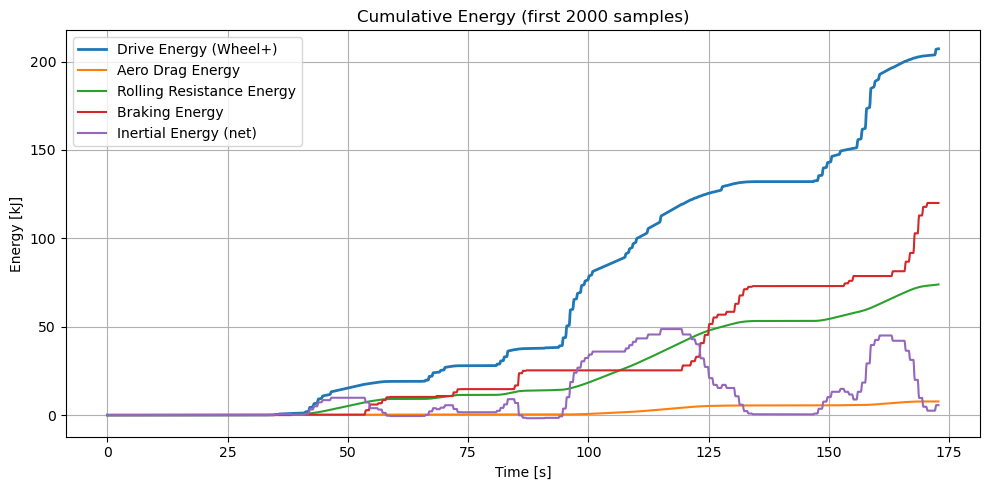

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_drive [kJ]'],   label='Drive Energy (Wheel+)', linewidth=2)
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_aero [kJ]'],    label='Aero Drag Energy')
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_roll [kJ]'],    label='Rolling Resistance Energy')
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_brake [kJ]'],   label='Braking Energy')
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_inertia [kJ]'], label='Inertial Energy (net)')
plt.xlabel('Time [s]')
plt.ylabel('Energy [kJ]')
plt.title('Cumulative Energy (first 2000 samples)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

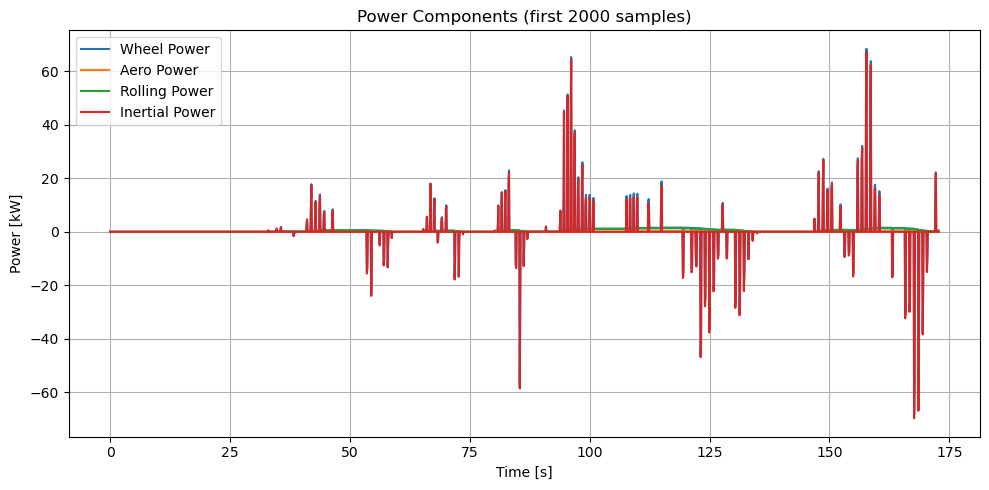

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(t, Leon_sub['P_total_wheel [W]'] / 1000, label='Wheel Power')
plt.plot(t, Leon_sub['P_aero [W]'] / 1000,        label='Aero Power')
plt.plot(t, Leon_sub['P_roll [W]'] / 1000,        label='Rolling Power')
plt.plot(t, Leon_sub['P_inertia [W]'] / 1000,     label='Inertial Power')
plt.xlabel('Time [s]')
plt.ylabel('Power [kW]')
plt.title('Power Components (first 2000 samples)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
def cumulative_energy(power_series, time_series):
    """
    power_series: pandas Series [W]
    time_series: pandas Series [s]
    returns: numpy array of cumulative energy [J]
    """
    p = np.asarray(power_series, dtype=float)
    t = np.asarray(time_series, dtype=float)
    
    E = np.zeros_like(p)
    dt = np.diff(t)
    # trapezoidal step: 0.5 * (P_i + P_{i-1}) * dt
    increments = 0.5 * (p[1:] + p[:-1]) * dt
    E[1:] = np.cumsum(increments)
    return E

In [30]:

N = min(2000, len(Leon1_table))
Leon_sub = Leon1_table.iloc[:N].copy()

t = Leon_sub['elapsed time']                   # [s]
v = Leon_sub['vehicle speed [m/s]']            # [m/s]


Leon_sub['P_aero [W]']    = Leon_sub['Faero [N]']    * v
Leon_sub['P_roll [W]']    = Leon_sub['Froll [N]']    * v
Leon_sub['P_inertia [W]'] = Leon_sub['Finertia [N]'] * v
Leon_sub['P_total_wheel [W]'] = Leon_sub['Wheel Power [W]']  # just rename for clarity

Leon_sub['P_drive [W]']  = np.clip(Leon_sub['P_total_wheel [W]'], 0, None)
Leon_sub['P_brake [W]']  = np.clip(Leon_sub['P_total_wheel [W]'], None, 0)  # negative

In [31]:

Leon_sub['E_aero [J]']    = cumulative_energy(Leon_sub['P_aero [W]'],    t)
Leon_sub['E_roll [J]']    = cumulative_energy(Leon_sub['P_roll [W]'],    t)
Leon_sub['E_inertia [J]'] = cumulative_energy(Leon_sub['P_inertia [W]'], t)


Leon_sub['E_drive [J]']   = cumulative_energy(Leon_sub['P_drive [W]'],   t)


Leon_sub['E_brake [J]']   = cumulative_energy(-Leon_sub['P_brake [W]'],  t)


for col in ['E_aero [J]', 'E_roll [J]', 'E_inertia [J]', 'E_drive [J]', 'E_brake [J]']:
    Leon_sub[col.replace('[J]', '[kJ]')] = Leon_sub[col] / 1e3

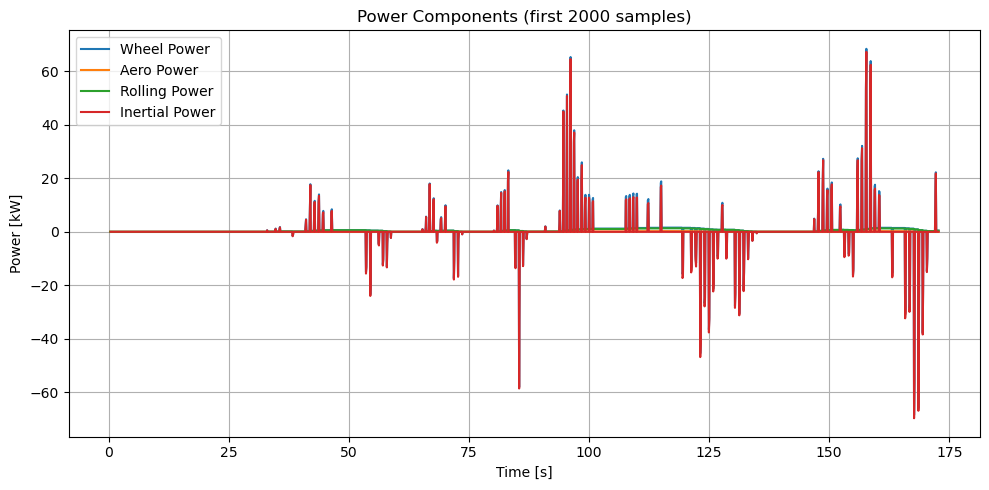

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(t, Leon_sub['P_total_wheel [W]'] / 1000, label='Wheel Power')
plt.plot(t, Leon_sub['P_aero [W]'] / 1000,        label='Aero Power')
plt.plot(t, Leon_sub['P_roll [W]'] / 1000,        label='Rolling Power')
plt.plot(t, Leon_sub['P_inertia [W]'] / 1000,     label='Inertial Power')
plt.xlabel('Time [s]')
plt.ylabel('Power [kW]')
plt.title('Power Components (first 2000 samples)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

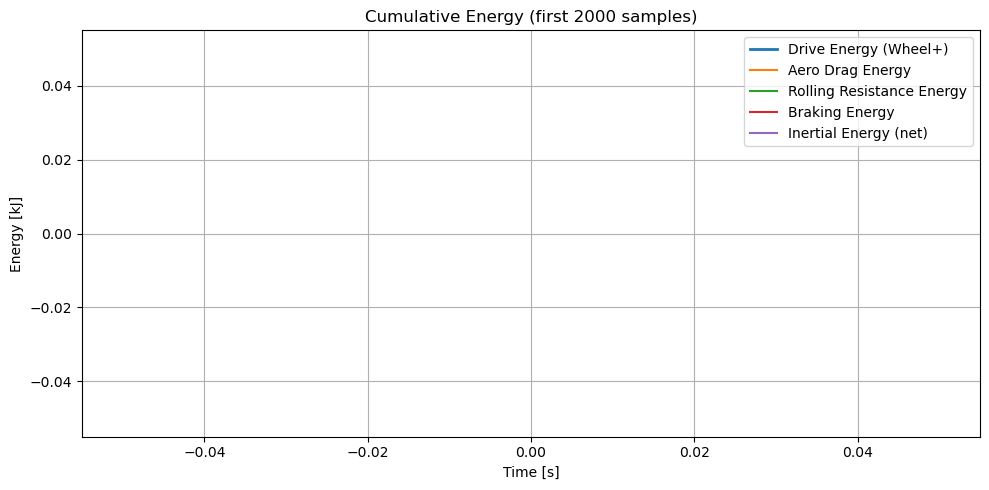

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_drive [kJ]'],   label='Drive Energy (Wheel+)', linewidth=2)
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_aero [kJ]'],    label='Aero Drag Energy')
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_roll [kJ]'],    label='Rolling Resistance Energy')
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_brake [kJ]'],   label='Braking Energy')
plt.plot(Leon_sub['elapsed time'], Leon_sub['E_inertia [kJ]'], label='Inertial Energy (net)')
plt.xlabel('Time [s]')
plt.ylabel('Energy [kJ]')
plt.title('Cumulative Energy (first 2000 samples)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# fix with IBM granite

In [34]:
Leon_sub.head(20)

,Time,Engine Coolant Temperature [Â°C],Intake Manifold Absolute Pressure [kPa],Engine RPM [RPM],Vehicle Speed Sensor [km/h],Intake Air Temperature [Â°C],Air Flow Rate from Mass Flow Sensor [g/s],Absolute Throttle Position [%],Ambient Air Temperature [Â°C],Accelerator Pedal Position D [%],...,E_aero [J],E_roll [J],E_inertia [J],E_drive [J],E_brake [J],E_aero [kJ],E_roll [kJ],E_inertia [kJ],E_drive [kJ],E_brake [kJ]
0,1900-01-01 07:16:30.444,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1900-01-01 07:16:30.535,31,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1900-01-01 07:16:30.625,31,96.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1900-01-01 07:16:30.716,31,96.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1900-01-01 07:16:30.814,31,96.0,0.0,0.0,22.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1900-01-01 07:16:30.895,31,96.0,0.0,0.0,22.0,0.91,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1900-01-01 07:16:30.987,31,96.0,0.0,0.0,22.0,0.91,89.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1900-01-01 07:16:31.075,31,96.0,0.0,0.0,22.0,0.91,89.0,21.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1900-01-01 07:16:31.167,31,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1900-01-01 07:16:31.257,31,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
